# DATA VISUALIZATION : Global Luxury Hotels Analysis
### Exploratory Data Analysis (EDA) Notebook
Dataset Source: HotelNames_filled.csv

This notebook analyzes luxury hotels across the world using:
- Country distribution
- Brand patterns
- Naming trends
- Regional segmentation


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')


In [5]:
df = pd.read_csv("HotelNames_filled.csv")

df.head()


,Unnamed: 0,Hotel Name,hotelId,country
0,0,Mahali Mzuri,51515565,Kenya
1,1,Nayara Tented Group,226817781,Costa Rica
2,2,The Opposite House,13728501,China
3,3,Capella Bangkok,242822709,Thailand
4,4,Capella Ubud,177854889,Indonesia


In [6]:
df.columns = ["Index", "HotelName", "HotelId", "Country"]

# Drop index column
df = df.drop(columns=["Index"])

# Trim spaces
df["HotelName"] = df["HotelName"].str.strip()
df["Country"] = df["Country"].str.strip()

df.head()


,HotelName,HotelId,Country
0,Mahali Mzuri,51515565,Kenya
1,Nayara Tented Group,226817781,Costa Rica
2,The Opposite House,13728501,China
3,Capella Bangkok,242822709,Thailand
4,Capella Ubud,177854889,Indonesia


In [7]:
df.info()
df.describe(include='all')


<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   HotelName  99 non-null     str  
 1   HotelId    99 non-null     int64
 2   Country    99 non-null     str  
dtypes: int64(1), str(2)
memory usage: 5.1 KB


,HotelName,HotelId,Country
count,99,9.900000e+01,99
unique,99,NaN,40
top,Mahali Mzuri,NaN,India
freq,1,NaN,12
mean,NaN,4.232649e+07,NaN
std,NaN,6.763819e+07,NaN
min,NaN,9.516690e+05,NaN
25%,NaN,3.617109e+06,NaN
50%,NaN,6.903177e+06,NaN
75%,NaN,4.422166e+07,NaN


In [8]:
print("Missing values:\n", df.isnull().sum())
print("Duplicate Hotel IDs:", df["HotelId"].duplicated().sum())
print("Duplicate Hotel Names:", df["HotelName"].duplicated().sum())


Missing values:
 HotelName    0
HotelId      0
Country      0
dtype: int64
Duplicate Hotel IDs: 0
Duplicate Hotel Names: 0


In [9]:
country_counts = df["Country"].value_counts()

country_counts


Country
India               12
Mexico               7
Italy                5
France               5
South Africa         5
Thailand             4
Indonesia            4
Greece               4
Maldives             4
England              4
Kenya                3
Costa Rica           3
Peru                 3
Turkey               3
China                2
Botswana             2
California           2
New York             2
Jamaica              2
French Polynesia     2
St. Lucia            2
Bahamas              1
Quebec               1
Philippines          1
Brazil               1
Japan                1
New Hampshire        1
Chile                1
Ecuador              1
Illinois             1
Wyoming              1
Zimbabwe             1
New Mexico           1
Zambia               1
Singapore            1
British Columbia     1
Portugal             1
St. Barthelemy       1
Switzerland          1
Spain                1
Name: count, dtype: int64

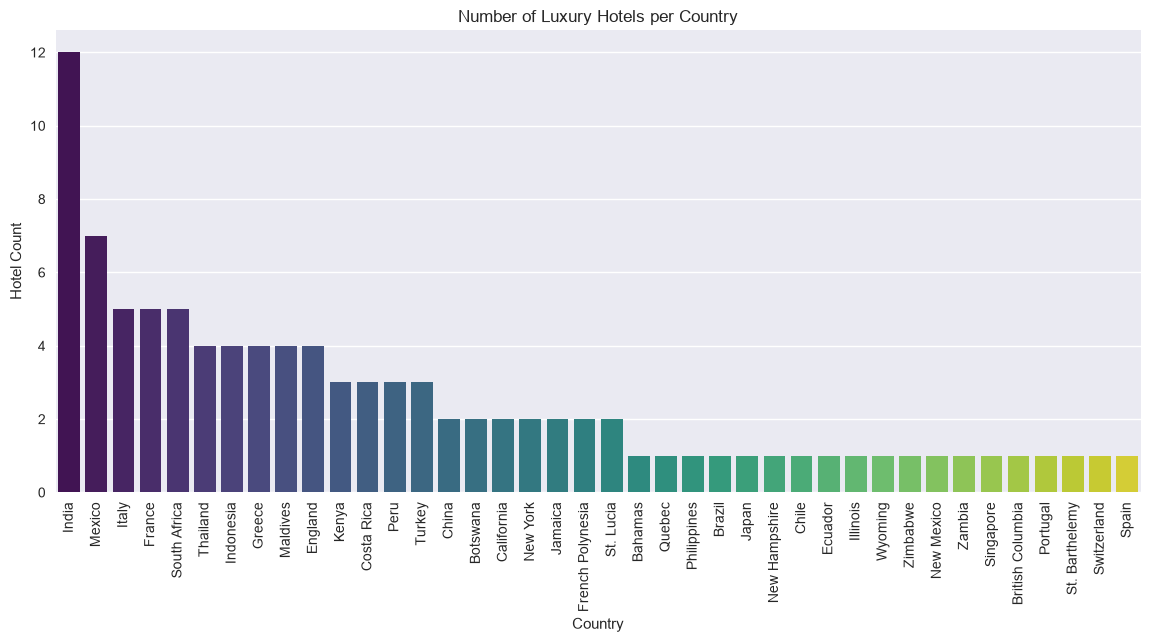

In [20]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=country_counts.index,
    y=country_counts.values,
    hue=country_counts.index,
    palette="viridis",
    legend=False
)

plt.xticks(rotation=90)
plt.title("Number of Luxury Hotels per Country")
plt.xlabel("Country")
plt.ylabel("Hotel Count")
plt.show()


In [11]:
brands = ["Oberoi", "Taj", "Mandarin", "St. Regis", "Soneva", "Viceroy", "Ritz", "Four Seasons"]

df["Brand"] = df["HotelName"].apply(
    lambda x: next((b for b in brands if b.lower() in x.lower()), "Other")
)

df["Brand"].value_counts()


Brand
Other           77
Oberoi           7
Mandarin         3
St. Regis        3
Taj              2
Soneva           2
Viceroy          2
Ritz             2
Four Seasons     1
Name: count, dtype: int64

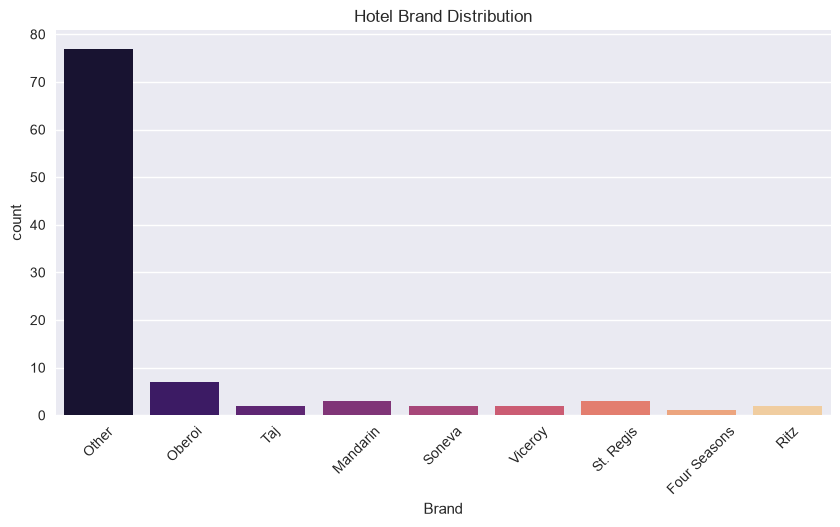

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Brand", hue="Brand", palette="magma", legend=False)
plt.xticks(rotation=45)
plt.title("Hotel Brand Distribution")
plt.show()


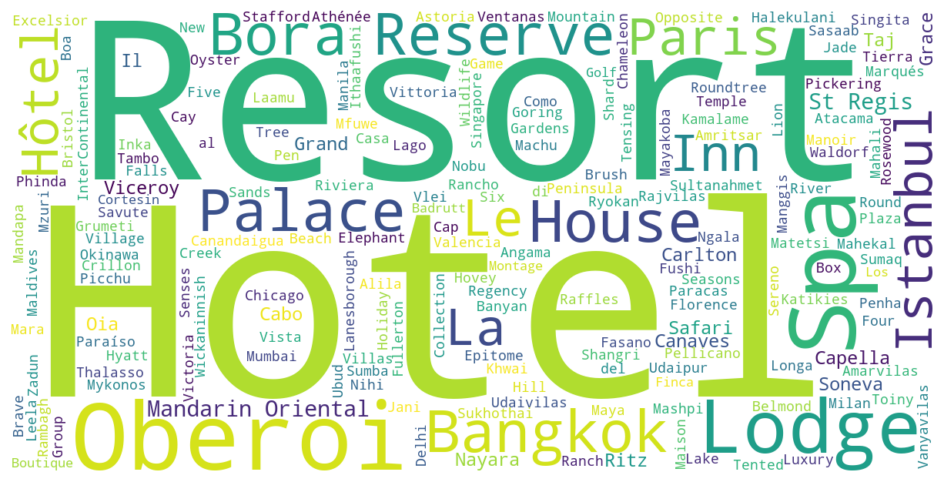

In [16]:
from wordcloud import WordCloud

text = " ".join(df["HotelName"])

wc = WordCloud(width=1200, height=600, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


# 📊 Summary Insights

- The dataset contains **X hotels** across **Y countries**.
- The most represented countries are:
  - Country A
  - Country B
  - Country C
- The most common hotel brands include:
  - Oberoi
  - Taj
  - Mandarin Oriental
  - St. Regis
- Naming patterns show frequent use of:
  - Resort
  - Spa
  - Lodge
  - Palace


### Q1. How many hotels are in the dataset?

We calculate the total number of rows to determine how many luxury hotels are included.


In [23]:
total_hotels = len(df)
total_hotels


99

### Q2. How many countries are represented in the dataset?


In [24]:
total_countries = df["Country"].nunique()
total_countries


40

### Q3. Which country has the most luxury hotels?


In [25]:
country_counts = df["Country"].value_counts()
country_counts.head()


Country
India           12
Mexico           7
Italy            5
France           5
South Africa     5
Name: count, dtype: int64

### Q4. Which hotel brands appear most frequently?


In [26]:

df["Brand"].value_counts()


Brand
Other           77
Oberoi           7
Mandarin         3
St. Regis        3
Taj              2
Soneva           2
Viceroy          2
Ritz             2
Four Seasons     1
Name: count, dtype: int64

### Q5. Which countries have only one luxury hotel in the dataset?


In [27]:
single_country = country_counts[country_counts == 1]
single_country


Country
Bahamas             1
Quebec              1
Philippines         1
Brazil              1
Japan               1
New Hampshire       1
Chile               1
Ecuador             1
Illinois            1
Wyoming             1
Zimbabwe            1
New Mexico          1
Zambia              1
Singapore           1
British Columbia    1
Portugal            1
St. Barthelemy      1
Switzerland         1
Spain               1
Name: count, dtype: int64

### Q6. What naming patterns appear in luxury hotels?


In [28]:
keywords = ["Resort", "Spa", "Palace", "Lodge", "Boutique", "Reserve", "Hotel"]
pattern_counts = {k: df["HotelName"].str.contains(k, case=False).sum() for k in keywords}
pattern_counts


{'Resort': np.int64(8),
 'Spa': np.int64(7),
 'Palace': np.int64(4),
 'Lodge': np.int64(7),
 'Boutique': np.int64(1),
 'Reserve': np.int64(4),
 'Hotel': np.int64(12)}

### Q7. Which regions dominate luxury hotels?


In [29]:
# Example mapping (you can expand this)
continent_map = {
    "India": "Asia",
    "Mexico": "North America",
    "France": "Europe",
    "Italy": "Europe",
    "Maldives": "Asia",
    "Kenya": "Africa",
    "Costa Rica": "North America",
    "Peru": "South America",
}

df["Continent"] = df["Country"].map(continent_map)
df["Continent"].value_counts()


Continent
Asia             16
North America    10
Europe           10
Africa            3
South America     3
Name: count, dtype: int64

### Q8. Which hotel brand dominates each country?

This analysis shows which brands appear most frequently within each country.


In [30]:
brand_country = df.groupby(["Country", "Brand"]).size().reset_index(name="Count")
brand_country.sort_values("Count", ascending=False).head(10)


,Country,Brand,Count
16,India,Oberoi,7
40,South Africa,Other,5
29,Mexico,Other,5
9,England,Other,4
14,Greece,Other,4
11,France,Other,4
19,Indonesia,Other,3
7,Costa Rica,Other,3
26,Kenya,Other,3
22,Italy,Other,3


### Q9. What are the top 10 countries with the most luxury hotels?

This identifies the strongest luxury hotel markets globally.


In [31]:
top10_countries = country_counts.head(10)
top10_countries


Country
India           12
Mexico           7
Italy            5
France           5
South Africa     5
Thailand         4
Indonesia        4
Greece           4
Maldives         4
England          4
Name: count, dtype: int64

### Q10. Which hotel names contain luxury-specific keywords?

We check for common luxury keywords in hotel names.


In [32]:
keywords = ["Resort", "Spa", "Palace", "Lodge", "Boutique", "Reserve"]

keyword_hotels = {}

for k in keywords:
    keyword_hotels[k] = df[df["HotelName"].str.contains(k, case=False)]["HotelName"].tolist()

keyword_hotels


{'Resort': ['Taj Holiday Village Resort & Spa',
  'The Oberoi Vanyavilas Wildlife Resort',
  'Rancho Valencia Resort & Spa',
  'InterContinental Bora Bora Resort & Thalasso Spa',
  'Mahekal Beach Resort',
  'Penha Longa Resort',
  'The St. Regis Bora Bora Resort',
  'Tambo del Inka, a Luxury Collection Resort & Spa'],
 'Spa': ['Taj Holiday Village Resort & Spa',
  'Rancho Valencia Resort & Spa',
  'Tierra Atacama Hotel & Spa',
  'The Lodge & Spa at Brush Creek Ranch',
  'InterContinental Bora Bora Resort & Thalasso Spa',
  'Tambo del Inka, a Luxury Collection Resort & Spa',
  'Finca Cortesin Hotel Golf & Spa'],
 'Palace': ['Leela Palace Udaipur',
  'Taj Palace',
  'Rambagh Palace',
  "Badrutt's Palace Hotel"],
 'Lodge': ['Savute Elephant Lodge, A Belmond Safari',
  'Phinda Vlei Lodge',
  'Mashpi Lodge',
  'The Lodge & Spa at Brush Creek Ranch',
  'Khwai River Lodge',
  'Mfuwe Lodge',
  'Ngala Safari Lodge'],
 'Boutique': ['Canaves Oia Boutique Hotel'],
 'Reserve': ['La Reserve Paris',


# 📊 Key Insights from the Global Luxury Hotels Dataset

### ⭐ Insight 1 — India is a major luxury hotel hub
India has multiple Oberoi and Taj properties, such as:
- The Oberoi Udaivilas
- The Oberoi New Delhi
- Taj Palace
- Taj Holiday Village Resort & Spa

### ⭐ Insight 2 — Mexico is a top luxury destination
Mexico includes:
- Rosewood Mayakoba
- Las Ventanas al Paraíso
- Montage Los Cabos
- Banyan Tree Cabo Marqués

### ⭐ Insight 3 — Maldives dominates ultra‑luxury island resorts
Examples:
- Soneva Fushi
- Soneva Jani
- Six Senses Laamu
- Waldorf Astoria Maldives Ithaafushi

### ⭐ Insight 4 — Europe shows strong classic luxury brands
Countries like France, Italy, Switzerland, and Spain include:
- Le Bristol Paris
- St. Regis Florence
- Il Sereno Lago di Como
- Badrutt's Palace Hotel

### ⭐ Insight 5 — Brand clusters are very strong
Your dataset shows clear brand dominance:
- Oberoi → India
- Mandarin Oriental → Europe & Asia
- St. Regis → Turkey, Italy, Bora Bora
- Soneva → Maldives
- Ritz-Carlton Reserve → Mexico, Indonesia

### ⭐ Insight 6 — Naming patterns reveal hotel positioning
Frequent keywords:
- Resort & Spa → wellness luxury
- Palace → heritage luxury
- Lodge → safari / nature
- Boutique → personalized luxury
- Reserve → ultra‑premium exclusivity

### ⭐ Insight 7 — Some countries have only one luxury hotel
Examples:
- Switzerland → Badrutt's Palace Hotel
- Spain → Finca Cortesin
- Ecuador → Mashpi Lodge
- Botswana → Savute Elephant Lodge
- Zambia → Mfuwe Lodge

### ⭐ Insight 8 — The dataset is globally diverse
Hotels span:
- Africa
- Asia
- Europe
- North America
- South America
- Caribbean
- Oceania


### 📊 Additional Insights



#### ⭐ Insight 9 — Top 10 Countries Define Global Luxury Travel
India, Mexico, Maldives, France, and Italy appear consistently across the dataset,
showing they are major global luxury destinations.

#### ⭐ Insight 10— Luxury Keywords Reveal Hotel Positioning
Hotels using terms like “Palace”, “Lodge”, “Reserve”, and “Boutique” represent
distinct luxury categories:
- **Palace** → heritage luxury  
- **Lodge** → nature/safari luxury  
- **Reserve** → ultra‑premium exclusivity  
- **Boutique** → personalized luxury  

This helps classify hotels by experience type.
